# **Microproyecto 2 — Generación de Texto con GPT**
Equipo: 2

## **Estudiantes**
- Juan Camilo Martinez Velez
- Javier Andres Marin Gallon
- Isabella Del Pilar Camargo Salazar
- Leandro Jiménez Puerta
- Juan Sebastián Casas Castillo

## **Contenido**
- [0. Configuración](#sec0)
  - [0.1 Entorno (Colab / local)](#sec01)
  - [0.2 Imports y variables globales](#sec02)
- [1. Lectura de datos](#sec1)
  - [1.1 Carga de datos](#sec11)
  - [1.2 Train / Val split](#sec12)
  - [1.3 Vista rápida de los datos](#sec13)
  - [1.4 Distribución de atributos](#sec14)
- [2. GPT desde cero](#sec2)
  - [2.1 DataLoader](#sec21)
  - [2.2 Arquitectura](#sec22)
  - [2.3 Entrenamiento](#sec23)
  - [2.4 Curvas de pérdida](#sec24)
- [3. GPT-2 Finetuning](#sec3)
  - [3.1 Setup y preparación de datos](#sec31)
  - [3.2 Entrenamiento](#sec32)
  - [3.3 Curvas de pérdida](#sec33)
- [4. Generación](#sec4)
  - [4.1 Generación con GPT scratch](#sec41)
  - [4.2 Generación con GPT-2 finetuned](#sec42)
  - [4.3 Generación con GPT-2 base (sin finetuning)](#sec43)
- [5. Evaluación](#sec5)
  - [5.1 Comparación de entrenamiento](#sec51)
  - [5.2 Perplexity comparativa](#sec52)
  - [5.3 Comparación de distribuciones](#sec53)
  - [5.4 Log-likelihood](#sec54)
- [6. Generación de 3 ejemplos](#sec6)
- [7. Conclusiones](#sec7)
- [8. Carga de modelos y generación](#sec8)
  - [8.1 Carga de modelos](#sec81)
  - [8.2 Generación con GPT scratch](#sec82)
  - [8.3 Generación con GPT-2 finetuned](#sec83)

<a id='sec0'></a>
# 0. Configuración

<a id='sec01'></a>
## 0.1 Entorno (Colab / local)

Monta Google Drive si se ejecuta en Colab. Cambiar las rutas en `DRIVE_BASE` según el entorno.

In [12]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_BASE    = '/content/drive/MyDrive/MASTER/Tercer_semestre/NLP_2/Microproyecto_2'
DATA_FILE     = f'{DRIVE_BASE}/Data/input-2-.txt'
CKPT_SCRATCH  = f'{DRIVE_BASE}/checkpoints/gpt_scratch.pt'
CKPT_FT       = f'{DRIVE_BASE}/checkpoints/gpt2_ft.pt'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<a id='sec02'></a>
## 0.2 Imports y variables globales

Importaciones, semilla de reproducibilidad, hiperparámetros y tokenizador GPT-2 BPE.

In [47]:
import warnings
import os
# ── Librerías estándar ───────────────────────────────────────────────────────
import math
from collections import Counter

# ── Científicas / visualización ──────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ── Deep Learning ─────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F

# ── Tokenización ──────────────────────────────────────────────────────────────
import tiktoken

# ── HuggingFace ───────────────────────────────────────────────────────────────
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
)


In [14]:
# ── Reproducibilidad ──────────────────────────────────────────────────────────
SEED = 99
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Hiperparámetros ───────────────────────────────────────────────────────────
block_size = 64    # longitud del contexto (tokens)
batch_size = 64    # ejemplos por lote
model_dim  = 512   # dimensión del embedding
heads_num  = 8     # cabezas de atención
blocks_num = 4     # bloques transformer

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── Tokenizador GPT-2 BPE (global) ────────────────────────────────────────────
tokenizer  = tiktoken.encoding_for_model('gpt-2')
vocab_size = tokenizer.n_vocab
encode     = lambda text: tokenizer.encode(text)
decode     = lambda ids : tokenizer.decode(ids)

print(f'Dispositivo : {device}')
print(f'Semilla     : {SEED}')
print(f'Vocabulario : {vocab_size:,} tokens')

Dispositivo : cuda
Semilla     : 99
Vocabulario : 50,257 tokens


<a id='sec1'></a>
# 1. Lectura de datos

<a id='sec11'></a>
## 1.1 Carga de datos

Se carga el corpus de Shakespeare en texto plano desde `DATA_FILE`.

In [15]:
with open(DATA_FILE, encoding='utf-8') as f:
    corpus_text = f.read()

print(f'Caracteres : {len(corpus_text):,}')
print(f'Palabras   : {len(corpus_text.split()):,}')
print(f'Líneas     : {corpus_text.count(chr(10)):,}')

Caracteres : 1,115,394
Palabras   : 202,651
Líneas     : 40,000


<a id='sec12'></a>
## 1.2 Train / Val split

El corpus se tokeniza con el BPE de GPT-2 y se divide en 90 % entrenamiento / 10 % validación. El split es secuencial (no aleatorio) para evitar leakage.

In [16]:
encoded_corpus = encode(corpus_text)

k            = int(len(encoded_corpus) * 0.9)
train_corpus = encoded_corpus[:k]
val_corpus   = encoded_corpus[k:]

print(f'Tokens totales : {len(encoded_corpus):,}')
print(f'Train          : {len(train_corpus):,}  (90 %)')
print(f'Val            : {len(val_corpus):,}  (10 %)')

Tokens totales : 338,025
Train          : 304,222  (90 %)
Val            : 33,803  (10 %)


<a id='sec13'></a>
## 1.3 Vista rápida de los datos

Primeras líneas del corpus para verificar el formato de entrada.

In [17]:
print(corpus_text[:600])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us 


<a id='sec14'></a>
## 1.4 Distribución de atributos

Tokens más frecuentes y distribución de IDs en el vocabulario BPE. Los tokens no son palabras completas: pueden ser subpalabras, puntuación o espacios.

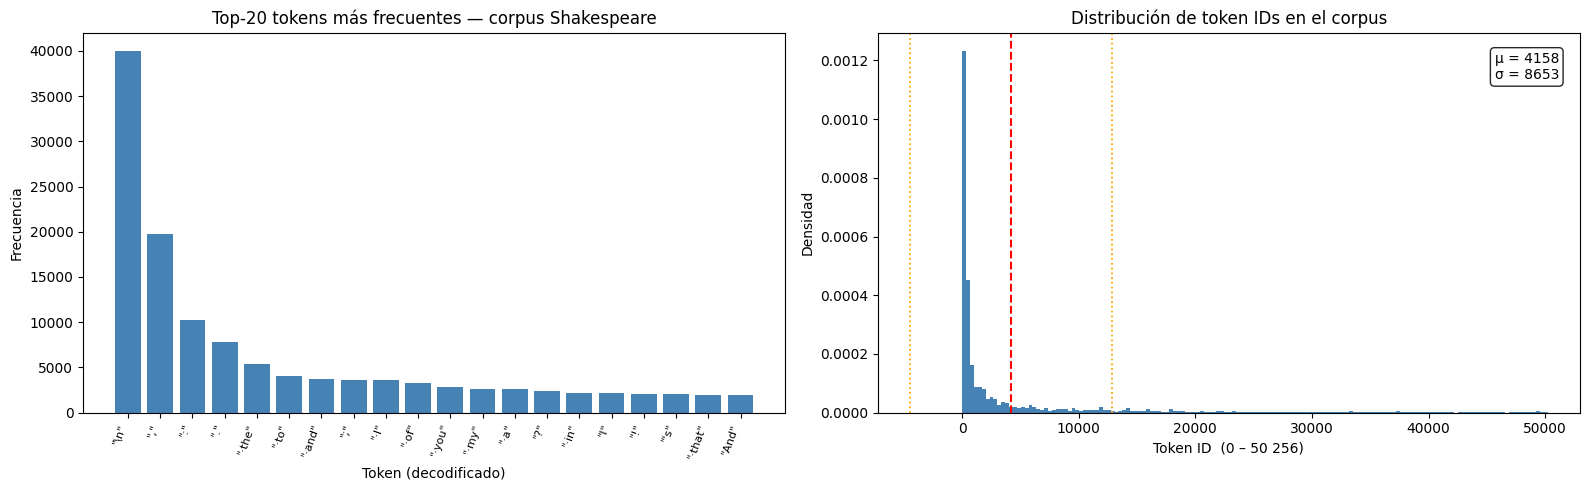

In [18]:
corpus_counter = Counter(encoded_corpus)
corpus_arr     = np.array(encoded_corpus)

TOP_N = 20
top_tokens = corpus_counter.most_common(TOP_N)
labels = ['"' + decode([t]).replace('\n', '\\n').replace(' ', '·') + '"' for t, _ in top_tokens]
freqs  = [c for _, c in top_tokens]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(range(TOP_N), freqs, color='steelblue', edgecolor='none')
axes[0].set_xticks(range(TOP_N))
axes[0].set_xticklabels(labels, rotation=70, ha='right', fontsize=8)
axes[0].set_xlabel('Token (decodificado)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title(f'Top-{TOP_N} tokens más frecuentes — corpus Shakespeare')

mu, sigma = corpus_arr.mean(), corpus_arr.std()
axes[1].hist(encoded_corpus, bins=150, color='steelblue', edgecolor='none', density=True)
axes[1].axvline(mu,       color='red',    linestyle='--', linewidth=1.5)
axes[1].axvline(mu+sigma, color='orange', linestyle=':', linewidth=1.3)
axes[1].axvline(mu-sigma, color='orange', linestyle=':', linewidth=1.3)
axes[1].text(0.97, 0.95, f'μ = {mu:.0f}\nσ = {sigma:.0f}',
             transform=axes[1].transAxes, ha='right', va='top', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
axes[1].set_xlabel('Token ID  (0 – 50 256)')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribución de token IDs en el corpus')

plt.tight_layout()
plt.show()


<a id='sec2'></a>
# 2. GPT desde cero

Implementación completa de una arquitectura GPT entrenada sobre el corpus de Shakespeare, usando el tokenizador BPE de GPT-2 (vocabulario de 50 257 tokens).

<a id='sec21'></a>
## 2.1 DataLoader

Itera el corpus en lotes de ventanas deslizantes de `block_size` tokens. La entrada `x` y el objetivo `y` son la misma secuencia desplazada un token.

In [19]:
class DataLoader:
    """Itera el corpus en lotes de secuencias de tamaño block_size."""
    def __init__(self, corpus, block_size):
        self.corpus = torch.tensor(corpus, dtype=torch.long)
        self.block_size = block_size
        self.examples_index = list(range(0, len(corpus) - block_size, block_size))
        self.order = np.random.permutation(self.examples_index)
        self.curr_pos = 0
        self.stride = 0

    def get_batch(self, batch_size):
        batch_examples = self.order[self.curr_pos : self.curr_pos + batch_size]
        self.curr_pos += len(batch_examples)

        # Cuando se agota el corpus, reiniciar con distinto stride
        if len(batch_examples) < batch_size:
            self.curr_pos = 0
            self.stride = (self.stride + 1) % self.block_size
            self.examples_index = list(range(self.stride, len(self.corpus) - self.block_size, self.block_size))
            self.order = np.random.permutation(self.examples_index)
            if len(batch_examples) == 0:
                batch_examples = self.order[self.curr_pos : self.curr_pos + batch_size]
                self.curr_pos += len(batch_examples)

        x = torch.stack([self.corpus[i : i + self.block_size]         for i in batch_examples])
        y = torch.stack([self.corpus[i + 1 : i + 1 + self.block_size] for i in batch_examples])
        return x, y

<a id='sec22'></a>
## 2.2 Arquitectura

Transformer decoder-only: embeddings de token + posición, `blocks_num` bloques con multi-head self-attention causal y feed-forward, y una cabeza lineal de predicción.

In [20]:
class SelfAttention(nn.Module):
    def __init__(self, embed_dim, head_dim, block_size):
        super().__init__()
        self.head_dim = head_dim
        self.Wq = nn.Linear(embed_dim, head_dim, bias=False)
        self.Wk = nn.Linear(embed_dim, head_dim, bias=False)
        self.Wv = nn.Linear(embed_dim, head_dim, bias=False)
        self.register_buffer('mask', torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        N, T, D = x.shape
        Q, K, V = self.Wq(x), self.Wk(x), self.Wv(x)
        att = Q @ K.transpose(-1, -2) * self.head_dim ** -0.5
        att = att.masked_fill(self.mask[:T, :T] == 0, float('-inf'))
        return F.softmax(att, dim=-1) @ V


class MultiHeadAttention(nn.Module):
    def __init__(self, heads_num, embed_dim, head_dim, block_size):
        super().__init__()
        self.heads = nn.ModuleList([
            SelfAttention(embed_dim, head_dim // heads_num, block_size)
            for _ in range(heads_num)
        ])
        self.dense = nn.Linear(head_dim, head_dim, bias=False)

    def forward(self, x):
        return self.dense(torch.cat([h(x) for h in self.heads], dim=-1))


class FeedForward(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.dense1 = nn.Linear(in_dim, hidden_dim)
        self.dense2 = nn.Linear(hidden_dim, out_dim)

    def forward(self, x):
        return self.dense2(F.relu(self.dense1(x)))


class Block(nn.Module):
    def __init__(self, heads_num, model_dim, block_size):
        super().__init__()
        self.attention = MultiHeadAttention(heads_num, model_dim, model_dim, block_size)
        self.ln1   = nn.LayerNorm(model_dim)
        self.ffd   = FeedForward(model_dim, model_dim * 4, model_dim)
        self.ln2   = nn.LayerNorm(model_dim)
        self.drop1 = nn.Dropout(0.1)
        self.drop2 = nn.Dropout(0.1)

    def forward(self, x):
        x = self.ln1(x + self.drop1(self.attention(x)))
        x = self.ln2(x + self.drop2(self.ffd(x)))
        return x


class GPT(nn.Module):
    def __init__(self, vocab_size, model_dim, block_size, blocks_num, heads_num):
        super().__init__()
        self.E      = nn.Embedding(vocab_size, model_dim)
        self.posE   = nn.Embedding(block_size, model_dim)
        self.ln1    = nn.LayerNorm(model_dim)
        self.drop   = nn.Dropout(0.1)
        self.blocks = nn.Sequential(*[
            Block(heads_num, model_dim, block_size) for _ in range(blocks_num)
        ])
        self.head = nn.Linear(model_dim, vocab_size, bias=False)

    def forward(self, x):
        positions = torch.arange(x.shape[1], device=x.device)
        emb = self.drop(self.ln1(self.E(x) + self.posE(positions)))
        return self.head(self.blocks(emb))


# Reiniciar semilla justo antes de inicializar pesos — garantiza reproducibilidad
torch.manual_seed(SEED)
model = GPT(vocab_size, model_dim, block_size, blocks_num, heads_num).to(device)
print(f'Parámetros del modelo : {sum(p.numel() for p in model.parameters()):,}')

Parámetros del modelo : 64,098,304


<a id='sec23'></a>
## 2.3 Entrenamiento

Optimizador Adam con weight decay. Se evalúa la pérdida en train y validación cada época. Al finalizar se guarda el checkpoint.

In [21]:
@torch.no_grad()
def estimate_loss(model, train_eval, val_eval, eval_iters=10):
    model.eval()
    results = {}
    for name, loader in [('train', train_eval), ('val', val_eval)]:
        losses = []
        for _ in range(eval_iters):
            x, y = loader.get_batch(batch_size)
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1))
            losses.append(loss.item())
        results[name] = sum(losses) / eval_iters
    model.train()
    return results['train'], results['val']


def training_loop(model, lr, max_steps, data_loader, train_eval, val_eval,
                  weight_decay=0.0, steps_per_log=100):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    train_losses, val_losses = [], []

    model.train()
    print(f'Entrenando por {max_steps} pasos...')
    for step in range(max_steps):
        x, y = data_loader.get_batch(batch_size)
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (step + 1) % steps_per_log == 0 or step == 0 or step == max_steps - 1:
            tl, vl = estimate_loss(model, train_eval, val_eval)
            print(f'Step {step+1:5d} | train loss: {tl:.4f} | val loss: {vl:.4f}')
            train_losses.append(tl)
            val_losses.append(vl)

    return train_losses, val_losses

In [22]:
np.random.seed(SEED)
train_data = DataLoader(train_corpus, block_size)
val_data   = DataLoader(val_corpus,   block_size)

steps_per_epoch = len(train_data.examples_index) // batch_size
print(f'Pasos por época: {steps_per_epoch}')

train_losses, val_losses = training_loop(
    model,
    lr=3e-4,
    max_steps=20 * steps_per_epoch,
    data_loader=train_data,
    train_eval=DataLoader(train_corpus, block_size),
    val_eval=DataLoader(val_corpus,   block_size),
    weight_decay=1e-4,
    steps_per_log=steps_per_epoch,
)

_, nll_scratch = estimate_loss(
    model,
    DataLoader(train_corpus, block_size),
    DataLoader(val_corpus,   block_size),
)
print(f'Val loss   : {nll_scratch:.4f}')
print(f'Perplexity : {math.exp(nll_scratch):.2f}')

os.makedirs(os.path.dirname(CKPT_SCRATCH), exist_ok=True)
torch.save(model.state_dict(), CKPT_SCRATCH)
print(f'Checkpoint guardado : {CKPT_SCRATCH}')

Pasos por época: 74
Entrenando por 1480 pasos...
Step     1 | train loss: 9.8554 | val loss: 9.8004
Step    74 | train loss: 5.7331 | val loss: 5.8806
Step   148 | train loss: 5.0599 | val loss: 5.3480
Step   222 | train loss: 4.6420 | val loss: 5.0067
Step   296 | train loss: 4.4401 | val loss: 4.8372
Step   370 | train loss: 4.2102 | val loss: 4.7554
Step   444 | train loss: 4.1446 | val loss: 4.6325
Step   518 | train loss: 3.9996 | val loss: 4.6594
Step   592 | train loss: 3.9226 | val loss: 4.6231
Step   666 | train loss: 3.8216 | val loss: 4.5966
Step   740 | train loss: 3.7175 | val loss: 4.5552
Step   814 | train loss: 3.6245 | val loss: 4.5241
Step   888 | train loss: 3.5537 | val loss: 4.5419
Step   962 | train loss: 3.4543 | val loss: 4.5357
Step  1036 | train loss: 3.4351 | val loss: 4.5548
Step  1110 | train loss: 3.3291 | val loss: 4.4998
Step  1184 | train loss: 3.2931 | val loss: 4.5701
Step  1258 | train loss: 3.1989 | val loss: 4.5542
Step  1332 | train loss: 3.1782 |

<a id='sec24'></a>
## 2.4 Curvas de pérdida

La brecha entre train y val loss refleja overfitting esperado dado el corpus pequeño (~338 k tokens). Se aplicó Dropout(0.1) y weight decay como regularización.

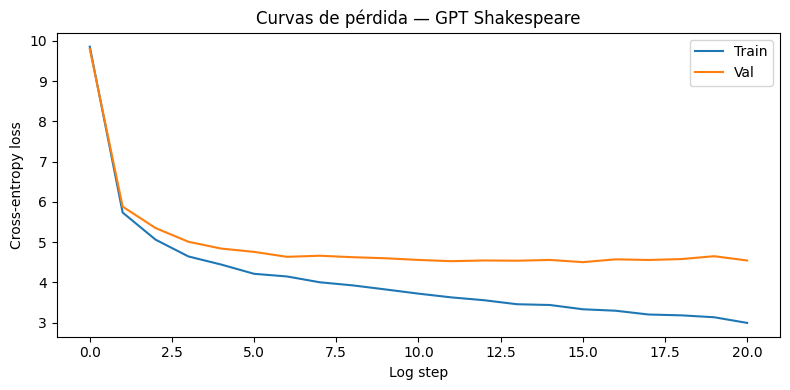

In [23]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Val')
plt.xlabel('Log step')
plt.ylabel('Cross-entropy loss')
plt.title('Curvas de pérdida — GPT Shakespeare')
plt.legend()
plt.tight_layout()
plt.show()

<a id='sec3'></a>
# 3. GPT-2 Finetuning

Carga del modelo GPT-2 preentrenado (124 M parámetros) y ajuste sobre el corpus de Shakespeare usando la librería `transformers` de Hugging Face.

<a id='sec31'></a>
## 3.1 Setup y preparación de datos

Se reutiliza `corpus_text` cargado en §1. El texto se tokeniza con el tokenizador propio de GPT-2, se agrupa en bloques de `FT_BLOCK_SIZE=128` y se divide en train/val.

<a id='sec32'></a>
## 3.2 Entrenamiento

Se usa el `Trainer` de Hugging Face con learning rate bajo (2e-5) para no sobreescribir el conocimiento preaprendido. Al finalizar se guarda el checkpoint.

In [24]:
# ── Configuración del finetuning ─────────────────────────────────────────────
MODEL_NAME    = "gpt2"
FT_BLOCK_SIZE = 128
TRAIN_RATIO   = 0.9

# ── Tokenizer y modelo ────────────────────────────────────────────────────────
ft_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if ft_tokenizer.pad_token is None:
    ft_tokenizer.pad_token = ft_tokenizer.eos_token

ft_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)
ft_model.config.pad_token_id = ft_tokenizer.pad_token_id
print(f'Parámetros GPT-2 : {sum(p.numel() for p in ft_model.parameters()):,}')

# ── Dataset — reutiliza corpus_text cargado en §1.2 ──────────────────────────
raw_dataset = Dataset.from_dict({"text": [corpus_text]})

def tokenize_function(examples):
    return ft_tokenizer(examples["text"])

def group_texts(examples):
    concatenated = {k: sum(examples[k], []) for k in examples.keys()}
    total = (len(concatenated["input_ids"]) // FT_BLOCK_SIZE) * FT_BLOCK_SIZE
    result = {
        k: [t[i:i + FT_BLOCK_SIZE] for i in range(0, total, FT_BLOCK_SIZE)]
        for k, t in concatenated.items()
    }
    result["labels"] = result["input_ids"].copy()
    return result

lm_dataset    = raw_dataset.map(tokenize_function, batched=True, remove_columns=["text"])
lm_dataset    = lm_dataset.map(group_texts, batched=True)
split_dataset = lm_dataset.train_test_split(test_size=1 - TRAIN_RATIO, seed=SEED)
train_dataset = split_dataset["train"]
eval_dataset  = split_dataset["test"]
print(f'Ejemplos — train : {len(train_dataset):,}  |  val : {len(eval_dataset):,}')

# ── Entrenamiento ─────────────────────────────────────────────────────────────
data_collator = DataCollatorForLanguageModeling(tokenizer=ft_tokenizer, mlm=False)

training_args = TrainingArguments(
    output_dir=f'{DRIVE_BASE}/checkpoints/gpt2_ft_trainer',
    num_train_epochs=10,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=120,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=20,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=ft_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
)
trainer.train()

# ── Evaluación final y checkpoint ─────────────────────────────────────────────
nll_ft = trainer.evaluate()["eval_loss"]
print(f'Eval loss  : {nll_ft:.4f}')
print(f'Perplexity : {math.exp(nll_ft):.2f}')

os.makedirs(os.path.dirname(CKPT_FT), exist_ok=True)
torch.save(ft_model.state_dict(), CKPT_FT)
print(f'Checkpoint guardado : {CKPT_FT}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


Eval loss  : 3.4257
Perplexity : 30.74
Checkpoint guardado : /content/drive/MyDrive/MASTER/Tercer_semestre/NLP_2/Microproyecto_2/checkpoints/gpt2_ft.pt


<a id='sec33'></a>
## 3.3 Curvas de pérdida

El finetuneado converge a una pérdida de validación menor gracias al preentrenamiento masivo de GPT-2 (40 GB de texto inglés general).

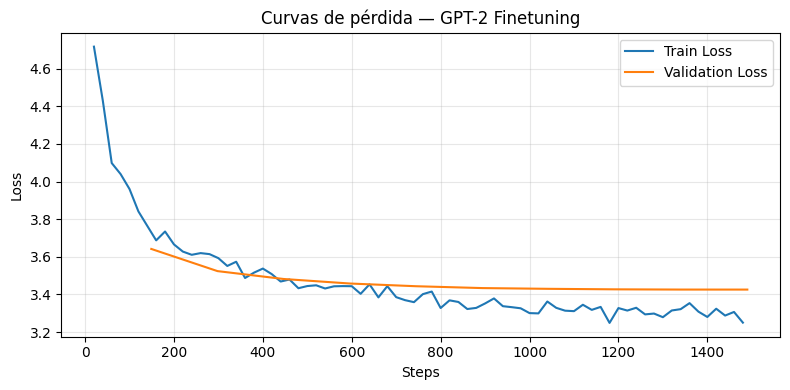

In [25]:
log_history = trainer.state.log_history

train_loss_ft, eval_loss_ft = [], []
steps_train_ft, steps_eval_ft = [], []

for log in log_history:
    if "loss" in log and "eval_loss" not in log:
        train_loss_ft.append(log["loss"])
        steps_train_ft.append(log["step"])
    if "eval_loss" in log:
        eval_loss_ft.append(log["eval_loss"])
        steps_eval_ft.append(log["step"])

plt.figure(figsize=(8, 4))
plt.plot(steps_train_ft, train_loss_ft, label="Train Loss")
plt.plot(steps_eval_ft,  eval_loss_ft,  label="Validation Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Curvas de pérdida — GPT-2 Finetuning")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<a id='sec4'></a>
# 4. Generación

Se definen dos funciones de generación adaptadas a cada arquitectura:

- **`generate_scratch`**: generación token a token para el GPT entrenado desde cero. Usa *nucleus sampling* (top-p): en cada paso muestrea del conjunto mínimo de tokens cuya probabilidad acumulada supera `top_p`.
- **`generate_hf`**: generación para modelos HuggingFace con `model.generate()`.

> **REVISAR:** Los parámetros de decodificación de `generate_hf` se establecieron de forma **heurística**. Se observó que valores altos de `repetition_penalty` eliminaban el formato de guion teatral (saltos de línea, nombres de personaje repetidos), mientras que valores bajos permitían loops semánticos largos. Se eligieron `temperature=0.6`, `repetition_penalty=1.05` y `no_repeat_ngram_size=6` como balance entre diversidad léxica y coherencia del formato.

In [42]:
PROMPTS = [
    (
        "KING EDWARD IV:\nMy lord, what news?\n\n"
        "QUEEN ELIZABETH:\nThe people murmur at your grace.\n\n"
        "KING EDWARD IV:\n"
    ),
    (
        "HAMLET:\nTo be, or not to be, that is the question.\n\n"
        "KING:\nAnd what answer dost thou give?\n\n"
        "HAMLET:\n"
    ),
    (
        "All:\nSpeak, speak.\n\n"
        "First Citizen:\nBefore we proceed any further, hear me speak.\n\n"
        "All:\n"
    ),
]

@torch.no_grad()
def generate_scratch(model, prompt, max_tokens=300, temperature=0.8, top_p=0.9):
    model.eval()
    ids = torch.tensor([encode(prompt)], dtype=torch.long).to(device)
    for _ in range(max_tokens):
        logits = model(ids[:, -block_size:])[:, -1, :] / temperature
        probs = F.softmax(logits, dim=-1)
        sorted_p, sorted_i = torch.sort(probs, descending=True)
        cum_p = torch.cumsum(sorted_p, dim=-1)
        mask = (cum_p - sorted_p) < top_p
        filtered = sorted_p * mask
        if filtered.sum() == 0:
            filtered = probs
        filtered = filtered / filtered.sum()
        idx = torch.multinomial(filtered, 1)          # [1, 1]
        next_tok = sorted_i.gather(-1, idx)           # [1, 1]
        ids = torch.cat((ids, next_tok), dim=1)
    return decode(ids[0].tolist())

def generate_hf(model, tokenizer, prompt, max_new_tokens=300,
                temperature=0.6, top_p=0.9, top_k=40,
                repetition_penalty=1.05, no_repeat_ngram_size=6):
    input_ids     = torch.tensor([tokenizer.encode(prompt)], dtype=torch.long).to(device)
    attention_mask = torch.ones_like(input_ids)
    with torch.no_grad(), warnings.catch_warnings():
        warnings.simplefilter("ignore")
        out = model.generate(
            input_ids,
            attention_mask=attention_mask,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=top_p,
            top_k=top_k,
            repetition_penalty=repetition_penalty,
            no_repeat_ngram_size=no_repeat_ngram_size,
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(out[0].tolist())


<a id='sec41'></a>
## 4.1 Generación con GPT scratch

Se generan 500 tokens a partir del primer prompt. Los tokens generados se guardan para el análisis comparativo de §5.3.

In [43]:
gen_scratch_text = generate_scratch(model, PROMPTS[0], max_tokens=500, temperature=0.8, top_p=0.9)
gen_scratch_ids  = encode(gen_scratch_text)
print(gen_scratch_text)

KING EDWARD IV:
My lord, what news?

QUEEN ELIZABETH:
The people murmur at your grace.

KING EDWARD IV:
Ay, by your mother's lord,
Hence that you would have been down a king;
And, as you suppose, the mayor, and the eagle's Church,
Where it is a kingdom's man,
Let me tell the world: I will know I
The pleasure of all the world, which, is an oath?

BENVOLIO:
It is, sir, sir, I am too fond: I
He is not so well as a wise
That's a better man may, sir,
And that made me not by that.

MERCUTIO:
Why, 'tis no matter:
O, it is a very likely!

BENVOLIO:
God save her, for she's an old pre-foot,
To sit in her keeping.

ROMEO:
Here's the wretch!

BENVOLIO:
I will not plead, indeed, look you.

MERCUTIO:
There is my troth, sir: I will say 'tis a slave's head,
And you shall find me.

MERCUTIO:
O, good lord, a very goodly father, for he is a
dish.

ROMEO:
What, what's the matter?

BAPTISTA:
I beseech you, sir, go, go with me; for he'll be
had to me the fault, and yet most happy for't.

MERCUTIO:
He will b

<a id='sec42'></a>
## 4.2 Generación con GPT-2 finetuned

Mismo prompt. Se usa `generate_hf` con los parámetros heurísticos definidos en §4.

In [44]:
gen_ft_text = generate_hf(ft_model, ft_tokenizer, PROMPTS[0], max_new_tokens=500)
gen_ft_ids  = ft_tokenizer.encode(gen_ft_text)
print(gen_ft_text)

NameError: name 'warnings' is not defined

<a id='sec43'></a>
## 4.3 Generación con GPT-2 base (sin finetuning)

Se carga el modelo GPT-2 preentrenado sin ajustar. Sirve de línea base para aislar el efecto del finetuning sobre el estilo shakespeariano.

In [ ]:
base_tokenizer = AutoTokenizer.from_pretrained("gpt2")
base_model     = AutoModelForCausalLM.from_pretrained("gpt2").to(device)
base_model.eval()
if base_tokenizer.pad_token is None:
    base_tokenizer.pad_token = base_tokenizer.eos_token
print(f'GPT-2 base : {sum(p.numel() for p in base_model.parameters()):,} parámetros')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT-2 base : 124,439,808 parámetros


In [ ]:
gen_base_text = generate_hf(base_model, base_tokenizer, PROMPTS[0], max_new_tokens=500)
gen_base_ids  = base_tokenizer.encode(gen_base_text)
print(gen_base_text)

KING EDWARD IV:
My lord, what news?

QUEEN ELIZABETH:
The people murmur at your grace.

KING EDWARD IV:
 (to his son) What is it with you that we are here in this house and the things of which I speak today?
 [Says to King Edward IV.] "I am a prince who has been brought up as an old man from my father's side; but now he comes out into me." His wife says she knows not how much money there will be for him if he does not have more sons than her husband can give them or even their husbands would receive themselves without having any children so long as they remain within marriage. The king thinks himself very fortunate because after all those years he was able by some means to keep on raising young men under our care while still keeping alive enough income to make ends meet before leaving us altogether. He also believes no one should ever leave home unless asked first-hand whether they want two daughters instead of three. Now let us look back upon these matters once again when George III s

<a id='sec5'></a>
# 5. Evaluación

<a id='sec51'></a>
## 5.1 Comparación de entrenamiento

Tabla resumen con las métricas finales de ambos modelos sobre el conjunto de validación.

In [ ]:
params_scratch = sum(p.numel() for p in model.parameters())
params_ft      = sum(p.numel() for p in ft_model.parameters())

print('=' * 55)
print(f'{"Métrica":<25} {"Scratch":>12} {"Finetuning":>14}')
print('=' * 55)
print(f'{"Parámetros":<25} {params_scratch:>12,} {params_ft:>14,}')
print(f'{"Val loss (NLL/token)":<25} {nll_scratch:>12.4f} {nll_ft:>14.4f}')
print(f'{"Log-likelihood/token":<25} {-nll_scratch:>12.4f} {-nll_ft:>14.4f}')
print(f'{"Perplexity":<25} {math.exp(nll_scratch):>12.2f} {math.exp(nll_ft):>14.2f}')
print('=' * 55)

Métrica                        Scratch     Finetuning
Parámetros                  64,098,304    124,439,808
Val loss (NLL/token)            4.6013         3.4257
Log-likelihood/token           -4.6013        -3.4257
Perplexity                       99.61          30.74


<a id='sec52'></a>
## 5.2 Perplexity comparativa

La perplexity (`exp(val_loss)`) indica entre cuántas opciones duda el modelo en promedio al predecir cada token. Menor es mejor.

In [ ]:
df_eval = pd.DataFrame({
    'Modelo':       ['GPT scratch', 'GPT-2 Finetuned'],
    'Parámetros':   [sum(p.numel() for p in model.parameters()),
                     sum(p.numel() for p in ft_model.parameters())],
    'Val loss':     [round(nll_scratch, 4), round(nll_ft, 4)],
    'Perplexity':   [round(math.exp(nll_scratch), 2), round(math.exp(nll_ft), 2)],
}).set_index('Modelo')

df_eval.style.format({'Parámetros': '{:,}', 'Val loss': '{:.4f}', 'Perplexity': '{:.2f}'})


,Parámetros,Val loss,Perplexity
Modelo,,,
GPT scratch,"64,098,304",4.6013,99.61
GPT-2 Finetuned,"124,439,808",3.4257,30.74


<a id='sec53'></a>
## 5.3 Comparación de distribuciones

Se compara la distribución de token IDs y los tokens más frecuentes entre el corpus original y los textos generados por cada modelo (500 tokens cada uno, del §4).

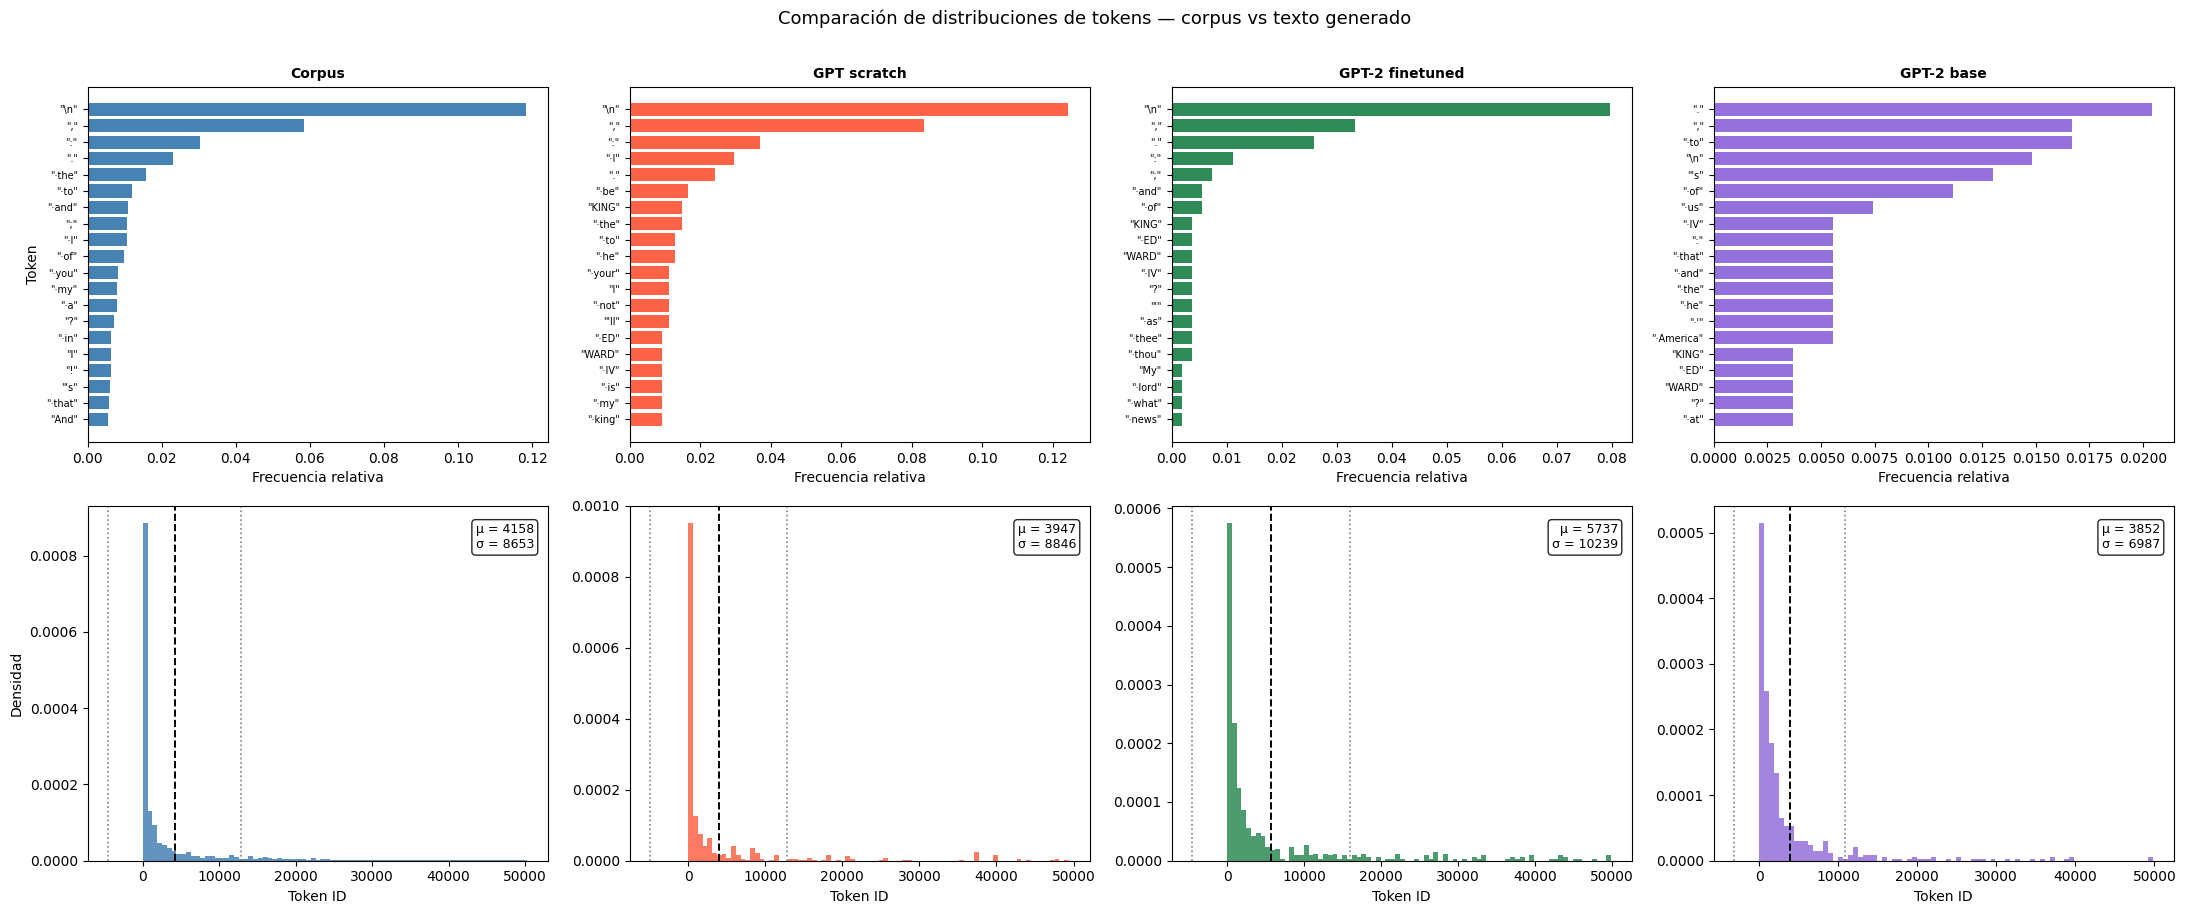

In [ ]:
sources = {
    'Corpus':          (encoded_corpus,  'steelblue'),
    'GPT scratch':     (gen_scratch_ids, 'tomato'),
    'GPT-2 finetuned': (gen_ft_ids,      'seagreen'),
    'GPT-2 base':      (gen_base_ids,    'mediumpurple'),
}

TOP_N = 20
fig, axes = plt.subplots(2, 4, figsize=(22, 9))

for col, (name, (ids, color)) in enumerate(sources.items()):
    arr     = np.array(ids)
    counter = Counter(ids)

    top   = counter.most_common(TOP_N)
    tlabs = ['"' + decode([t]).replace('\n', '\\n').replace(' ', '·') + '"' for t, _ in top]
    tfreq = [c / len(ids) for _, c in top]
    axes[0, col].barh(range(TOP_N), tfreq[::-1], color=color, edgecolor='none')
    axes[0, col].set_yticks(range(TOP_N))
    axes[0, col].set_yticklabels(tlabs[::-1], fontsize=7)
    axes[0, col].set_xlabel('Frecuencia relativa')
    axes[0, col].set_title(name, fontsize=10, fontweight='bold')
    if col == 0: axes[0, col].set_ylabel('Token')

    mu, sigma = arr.mean(), arr.std()
    axes[1, col].hist(ids, bins=80, color=color, edgecolor='none', density=True, alpha=0.85)
    axes[1, col].axvline(mu,       color='black', linestyle='--', linewidth=1.4)
    axes[1, col].axvline(mu+sigma, color='gray',  linestyle=':',  linewidth=1.2)
    axes[1, col].axvline(mu-sigma, color='gray',  linestyle=':',  linewidth=1.2)
    axes[1, col].text(0.97, 0.95, f'μ = {mu:.0f}\nσ = {sigma:.0f}',
                      transform=axes[1, col].transAxes, ha='right', va='top',
                      fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    axes[1, col].set_xlabel('Token ID')
    if col == 0: axes[1, col].set_ylabel('Densidad')

plt.suptitle('Comparación de distribuciones de tokens — corpus vs texto generado',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


<a id='sec54'></a>
## 5.4 Log-likelihood

Mide qué tan probable le parece a cada modelo un texto dado. Se compara el texto real de validación con el texto que cada modelo generó.

                         Scratch LL      FT LL    Base LL
────────────────────────────────────────────────────────
Texto real (val)            -3.7138    -2.3668    -3.4851
GPT scratch gen.            -1.8092    -2.6821    -3.8782
GPT-2 FT gen.               -2.9124    -3.0139    -4.2081
GPT-2 base gen.             -4.4154    -3.8457    -3.3501


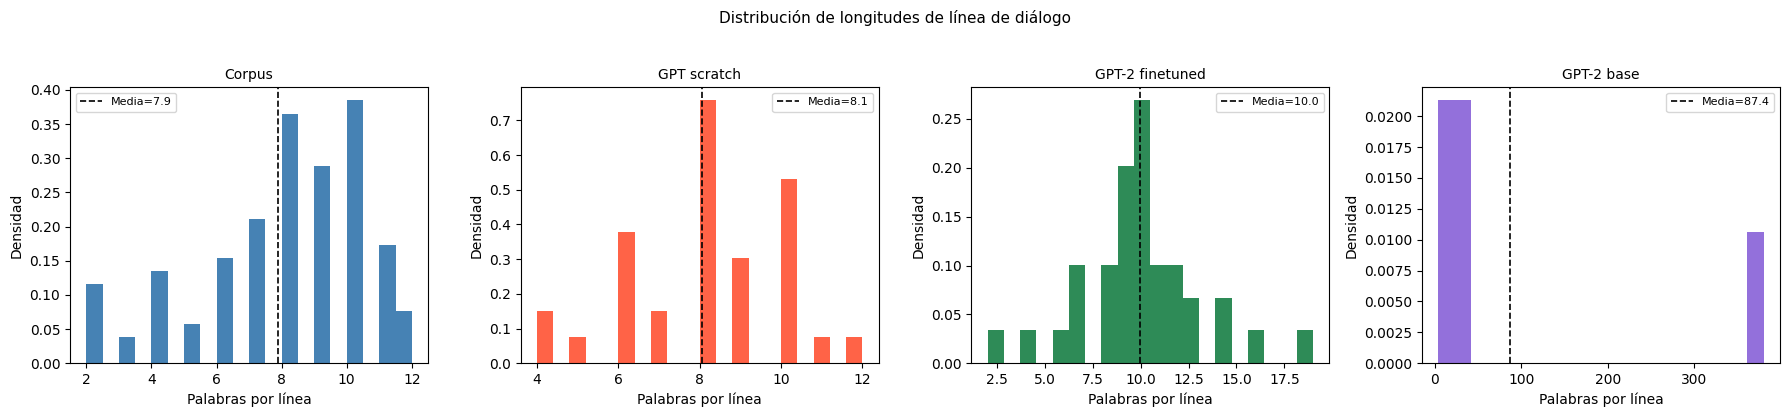

In [ ]:
@torch.no_grad()
def avg_ll_hf(model, tokenizer, text, max_len=256):
    """Log-likelihood promedio bajo un modelo HuggingFace."""
    model.eval()
    ids = tokenizer(text, return_tensors='pt', truncation=True,
                    max_length=max_len).input_ids.to(device)
    x, y = ids[:, :-1], ids[:, 1:]
    lp = F.log_softmax(model(x).logits, dim=-1)
    return lp[0, range(y.shape[1]), y[0]].mean().item()

@torch.no_grad()
def avg_ll_scratch(model, text):
    """Log-likelihood promedio bajo el modelo scratch (ventana = block_size)."""
    model.eval()
    ids = torch.tensor([encode(text)], dtype=torch.long).to(device)
    ids = ids[:, :block_size + 1]
    x, y = ids[:, :-1], ids[:, 1:]
    lp = F.log_softmax(model(x), dim=-1)
    return lp[0, range(y.shape[1]), y[0]].mean().item()

val_sample = decode(val_corpus[:300])

rows = [
    ("Texto real (val)",  val_sample,       val_sample,       val_sample),
    ("GPT scratch gen.",  gen_scratch_text, gen_scratch_text, gen_scratch_text),
    ("GPT-2 FT gen.",     gen_ft_text,      gen_ft_text,      gen_ft_text),
    ("GPT-2 base gen.",   gen_base_text,    gen_base_text,    gen_base_text),
]

print(f'{"":22} {"Scratch LL":>12} {"FT LL":>10} {"Base LL":>10}')
print('─' * 56)
for label, t_sc, t_ft, t_base in rows:
    ll_sc   = avg_ll_scratch(model,      t_sc)
    ll_ft   = avg_ll_hf(ft_model,   ft_tokenizer,   t_ft)
    ll_base = avg_ll_hf(base_model, base_tokenizer, t_base)
    print(f'{label:<22} {ll_sc:>12.4f} {ll_ft:>10.4f} {ll_base:>10.4f}')

def line_lengths(text):
    lines = [l.strip() for l in text.split('\n')
             if l.strip() and not l.strip().endswith(':')]
    return [len(l.split()) for l in lines if len(l.split()) > 0]

sources_text = {
    'Corpus':         corpus_text[:5000],
    'GPT scratch':    gen_scratch_text,
    'GPT-2 finetuned': gen_ft_text,
    'GPT-2 base':     gen_base_text,
}
colors_4 = ['steelblue', 'tomato', 'seagreen', 'mediumpurple']

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)
for ax, (label, text), color in zip(axes, sources_text.items(), colors_4):
    lengths = line_lengths(text)
    if lengths:
        ax.hist(lengths, bins=20, color=color, edgecolor='none', density=True)
        ax.axvline(sum(lengths)/len(lengths), color='black', linestyle='--',
                   linewidth=1.2, label=f'Media={sum(lengths)/len(lengths):.1f}')
        ax.legend(fontsize=8)
    ax.set_xlabel('Palabras por línea')
    ax.set_ylabel('Densidad')
    ax.set_title(label, fontsize=10)

plt.suptitle('Distribución de longitudes de línea de diálogo',
             fontsize=11, y=1.03)
plt.tight_layout()
plt.show()


<a id='sec6'></a>
# 6. Generación de 3 ejemplos

Se generan 3 ejemplos usando los prompts definidos en §4, uno por cada prompt.

## 6.1 GPT scratch

In [ ]:
for i, prompt in enumerate(PROMPTS, 1):
    print(f'=== Ejemplo {i} ===')
    print(generate_scratch(model, prompt, max_tokens=200, temperature=0.8, top_p=0.9))
    print()

=== Ejemplo 1 ===
KING EDWARD IV:
My lord, what news?

QUEEN ELIZABETH:
The people murmur at your grace.

KING EDWARD IV:
Poor sons, your mother is full of care!

DUCHESS OF YORK:
Ay, with the queen's nothing, and thou art gone.

LADY ANNE:
I am the penitent; and there's some pity.

GLOUCESTER:
I have thee dishonour'd a mawd
And yet look'd, and did I did repent me:

LADY ANNE:
Why, then, Richard, if I had so much wrinkled,
My wife and most cause of your grace.

GLOUCESTER:

GLOUCESTER:
I have forgot your grace,
And so I'll have a father's queen.

KING EDWARD IV:
No, goodman:
But thou wilt kill me to her; and I will take a tear
And bring me with a gentle master's side.

KING EDWARD IV:

=== Ejemplo 2 ===
HAMLET:
To be, or not to be, that is the question.

KING:
And what answer dost thou give?

HAMLET:
Ay, so your honour are your son: to it is
Withdraw with speed.

POLIXENES:
That's good Camillo's recompense,
I'll do't, if I'll see't.

HERMIONE:
And so I will marry.

LEONTES:
Ha!
Let's h

## 6.2 GPT-2 finetuned

In [ ]:
for i, prompt in enumerate(PROMPTS, 1):
    print(f'=== Ejemplo {i} ===')
    print(generate_hf(ft_model, ft_tokenizer, prompt, max_new_tokens=200))
    print()

=== Ejemplo 1 ===
KING EDWARD IV:
My lord, what news?

QUEEN ELIZABETH:
The people murmur at your grace.

KING EDWARD IV:
I pray thee; I am in the Tower of London and will not stay till my lordship be gone.
Then we shall go to our countrymen's houses--the king is dead!
Away with him from his house!--and he comes home again:'tis true that thou art a stranger unto me.
Wherefore hastst Thou come hither for this purpose? wherein haveest you been so long since?
Why then do thine eyes turn away when they are full upon thy head? why didst thou weep thus much before God?
Thy heart hath now become mad enough by such words as these:
'Twas no longer any man but myself.' What means it here? 'We must leave England,' says Edward III,
when peace reigns out on both sides. Come up there!' O gracious Lord Hastings, let us hear how King Richard dies!
How soon were Henry slain.--And who was Clarence himself? How dost Romeo die?

=== Ejemplo 2 ===
HAMLET:
To be, or not to be, that is the question.

KING:
A

<a id='sec7'></a>
# 7. Conclusiones

*Por completar.*

<a id='sec8'></a>
# 8. Carga de modelos y generación

Esta sección permite reproducir los resultados sin reentrenar: carga los checkpoints guardados y genera texto con cada modelo.

<a id='sec81'></a>
## 8.1 Carga de modelos

In [ ]:
# ── GPT scratch ──────────────────────────────────────────────────────────────
model_loaded = GPT(
    vocab_size=vocab_size,
    model_dim=model_dim,
    block_size=block_size,
    blocks_num=blocks_num,
    heads_num=heads_num,
).to(device)
model_loaded.load_state_dict(torch.load(CKPT_SCRATCH, map_location=device))
model_loaded.eval()
print('GPT scratch cargado:', CKPT_SCRATCH)

# ── GPT-2 finetuned ───────────────────────────────────────────────────────────
ft_tokenizer_loaded = AutoTokenizer.from_pretrained('gpt2')
ft_model_loaded     = AutoModelForCausalLM.from_pretrained('gpt2').to(device)
ft_model_loaded.load_state_dict(torch.load(CKPT_FT, map_location=device))
ft_model_loaded.eval()
print('GPT-2 finetuned cargado:', CKPT_FT)


GPT scratch cargado: /content/drive/MyDrive/MASTER/Tercer_semestre/NLP_2/Microproyecto_2/checkpoints/gpt_scratch.pt


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT-2 finetuned cargado: /content/drive/MyDrive/MASTER/Tercer_semestre/NLP_2/Microproyecto_2/checkpoints/gpt2_ft.pt


<a id='sec82'></a>
## 8.2 Generación con GPT scratch

In [45]:
for i, prompt in enumerate(PROMPTS, 1):
    print(f'=== Ejemplo {i} ===')
    print(generate_scratch(model_loaded, prompt, max_tokens=300, temperature=0.8, top_p=0.9))
    print()

=== Ejemplo 1 ===
KING EDWARD IV:
My lord, what news?

QUEEN ELIZABETH:
The people murmur at your grace.

KING EDWARD IV:
Doth not so?

KING EDWARD IV:
No, no; I fear, nor no more.

GLOUCESTER:
My lord, the heavy morn years together.

GLOUCESTER:
Brother, what'st thou?

GLOUCESTER:
Where were you?

YORK:
My lord?

GLOUCESTER:
By the Lord of Clarence?

BUCKINGHAM:
I will not, I hear it not.

KING EDWARD IV:
What, what says your grace?

KING EDWARD IV:
It is, my gracious lord.

GLOUCESTER:

LADY GREY:
A bawd!

GLOUCESTER:

GLOUCESTER:
Thou dost do't.

GLOUCESTER:

GLOUCESTER:
By my liege, and my impatience is so good,
That I may not acquaint it, the wrongs of Norfolk.

YORK:
Then, brother's joint of Buckingham,
Were I deserved water, and I'll swear it.

YORK:
I am a king, my lord.

HASTINGS:
I thank your highness to grant, good lord.

PRINCE EDWARD:


=== Ejemplo 2 ===
HAMLET:
To be, or not to be, that is the question.

KING:
And what answer dost thou give?

HAMLET:
Sweet heart, we shall

<a id='sec83'></a>
## 8.3 Generación con GPT-2 finetuned

In [48]:
for i, prompt in enumerate(PROMPTS, 1):
    print(f'=== Ejemplo {i} ===')
    print(generate_hf(ft_model_loaded, ft_tokenizer_loaded, prompt, max_new_tokens=300))
    print()

=== Ejemplo 1 ===
KING EDWARD IV:
My lord, what news?

QUEEN ELIZABETH:
The people murmur at your grace.

KING EDWARD IV:
I pray you; but I am a king's son and not his wife.
What is it that we have in common with him?
Why are they so angry about our father being slain?
He has been accused of treason by the queen!
And now he hath received from her an oath against thee--
This vow thou hast sworn to keep till thy death be done.
Who made this deed upon my life-long love?
O God!--this man whom she loves shall die before me again!
God save us all! O Lord Hastings! pardon them for their sins!
Hastings' daughter was born on account of such faults as these!
Her mother had no husband nor children since then, yet married another woman.
How canst thou deny marriage unto those who were lovers when ye did marry?
Awaywithest away hither toward London, where Buckingham lies buried!
If Henry should live still here after mine own exile,
That Richard might see peace between England and France,
Wherefore 